In [34]:
import sys, os
from collections import defaultdict, namedtuple
from enum import StrEnum, auto
import json
import re
import pprint

import numpy as np
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from matplotlib import pyplot as plt

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from model_registry import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect_2
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement
from torch_helpers import *

In [35]:
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    run_path='',
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/experiment/vae',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'run_path': '/home/misha/dev/mine/neurovision/run/vae',
 'self_fname': '/home/misha/dev/mine/neurovision/experiment/vae/vae.ipynb',
 'self_name': 'vae',
 'subproject_name': 'vae',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [37]:
# Set random seeds

torch.manual_seed(1)
torch.cuda.manual_seed(1)

In [38]:
# Define data loading step

batch_size = 256

kwargs = {'num_workers': 1, 'pin_memory': True}
train_loader = torch.utils.data.DataLoader(
    MNIST(CONFIG.mnist_path, train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    MNIST(CONFIG.mnist_path, train=False, transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=True, **kwargs)

In [39]:
# Defining the device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [40]:
# Defining the model

d = 20

class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, d ** 2),
            nn.ReLU(),
            nn.Linear(d ** 2, d * 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(d, d ** 2),
            nn.ReLU(),
            nn.Linear(d ** 2, 784),
            nn.Sigmoid(),
        )

    def reparameterise(self, mu, logvar):
        if self.training:
            std = logvar.mul(0.5).exp_()
            eps = std.data.new(std.size()).normal_()
            return eps.mul(std).add_(mu)
        else:
            return mu

    def forward(self, y):
        mu_logvar = self.encoder(y.view(-1, 784)).view(-1, 2, d)
        mu = mu_logvar[:, 0, :]
        logvar = mu_logvar[:, 1, :]
        z = self.reparameterise(mu, logvar) # aka sampling from MVN
        return self.decoder(z), mu, logvar

model = VAE().to(device)

In [41]:
# Setting the optimiser

learning_rate = 1e-3

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
)

In [42]:
# Reconstruction + KL divergence losses summed over all elements and batch

def loss_function(ỹ, y, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        ỹ, y.view(-1, 784), reduction='sum'
    )
    # KLD is aimed to keep sampled Z to resemble Guassian
    KLD = 0.5 * torch.sum(logvar.exp() - logvar - 1 + mu.pow(2))

    return BCE + KLD

In [55]:
# Displaying routine

def display_images(in_, out, n=1, label='', count=False, energy=None):
    for N in range(n):
        if in_ is not None:
            in_pic = in_.data.cpu().view(-1, 28, 28)
            plt.figure(figsize=(18, 4))
            plt.suptitle(label + ' – real test data / reconstructions', fontsize=16) #, color='w')
            for i in range(4):
                plt.subplot(1,4,i+1)
                plt.imshow(in_pic[i+4*N])
                plt.axis('off')
        out_pic = out.data.cpu().view(-1, 28, 28)
        plt.figure(figsize=(18, 6))
        for i in range(4):
            plt.subplot(1,4,i+1)
            plt.imshow(out_pic[i+4*N])
            plt.axis('off')
            c = 4 * N + i
            if count: plt.title(str(c))#, color='w')
            if count and energy is not None: plt.title(f'{c}, e={energy[c].item():.2f}') #, color='w')


====> Test set loss: 95.8477
====> Epoch: 1 Average loss: 104.6689
====> Test set loss: 96.0903
====> Epoch: 2 Average loss: 104.4607
====> Test set loss: 95.6160
====> Epoch: 3 Average loss: 104.3574
====> Test set loss: 95.6961
====> Epoch: 4 Average loss: 104.2494
====> Test set loss: 94.8938
====> Epoch: 5 Average loss: 104.0859
====> Test set loss: 95.9861
====> Epoch: 6 Average loss: 103.9492
====> Test set loss: 95.4349
====> Epoch: 7 Average loss: 103.8489
====> Test set loss: 94.5289
====> Epoch: 8 Average loss: 103.7205
====> Test set loss: 95.4433
====> Epoch: 9 Average loss: 103.6196
====> Test set loss: 95.0197
====> Epoch: 10 Average loss: 103.4989
====> Test set loss: 95.1272


/tmp/ipykernel_5553/3109962577.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(18, 4))


====> Epoch: 11 Average loss: 103.4554
====> Test set loss: 94.9837
====> Epoch: 12 Average loss: 103.3821
====> Test set loss: 94.8823
====> Epoch: 13 Average loss: 103.2173
====> Test set loss: 94.0359
====> Epoch: 14 Average loss: 103.1527
====> Test set loss: 94.4049
====> Epoch: 15 Average loss: 103.1270
====> Test set loss: 94.5278
====> Epoch: 16 Average loss: 102.9826
====> Test set loss: 94.5533
====> Epoch: 17 Average loss: 102.9766
====> Test set loss: 94.5626
====> Epoch: 18 Average loss: 102.8555
====> Test set loss: 94.4396
====> Epoch: 19 Average loss: 102.8551
====> Test set loss: 94.4871
====> Epoch: 20 Average loss: 102.7760
====> Test set loss: 93.8270


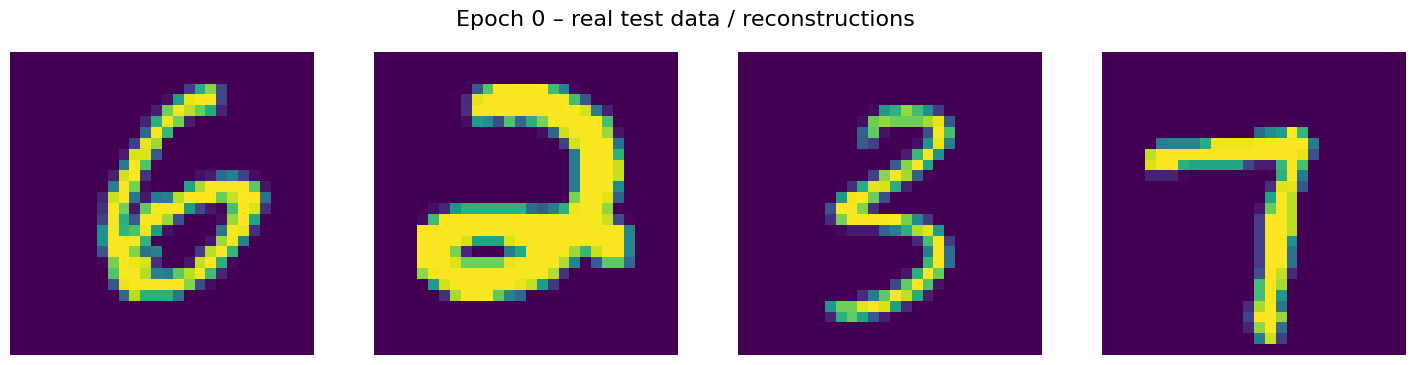

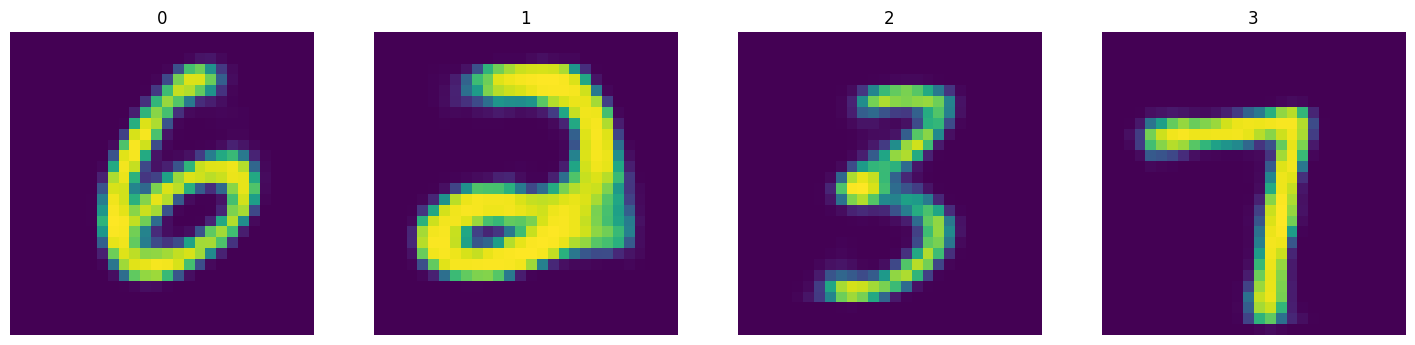

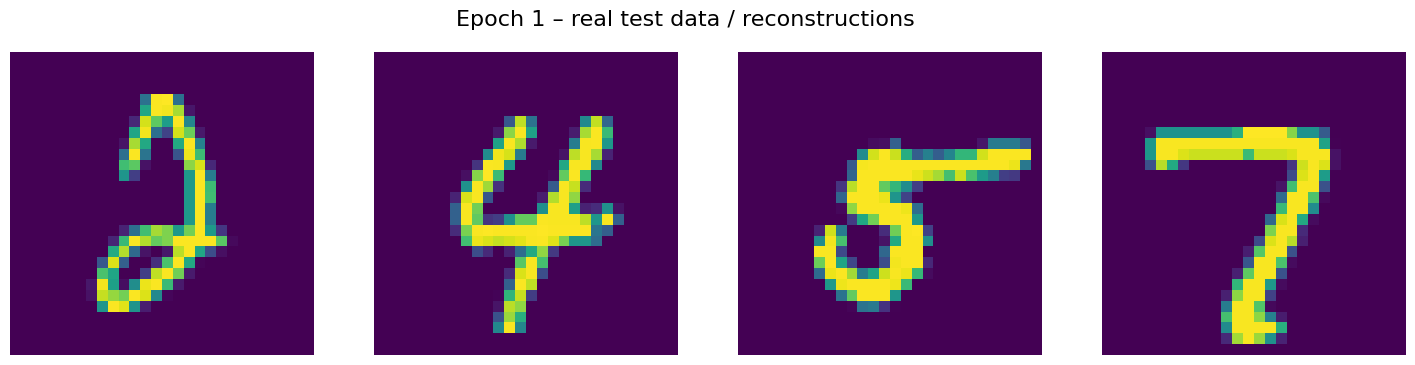

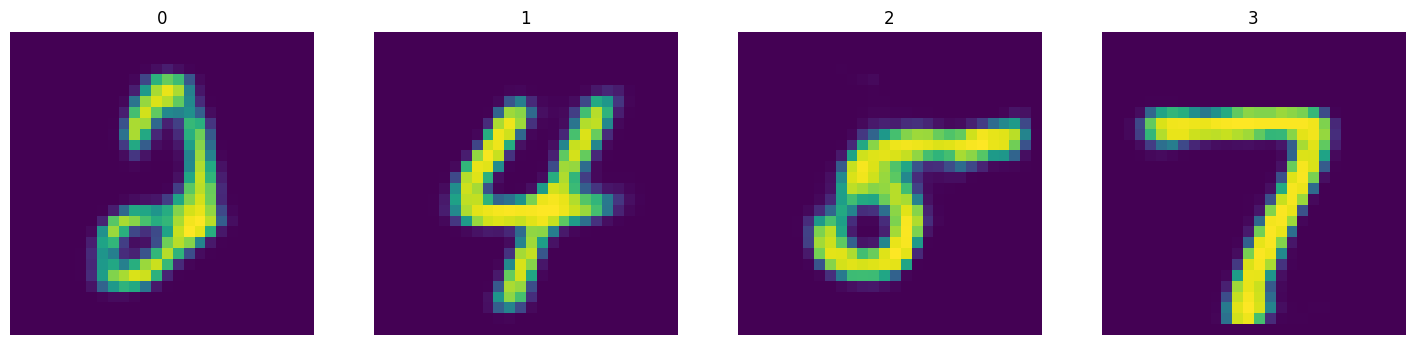

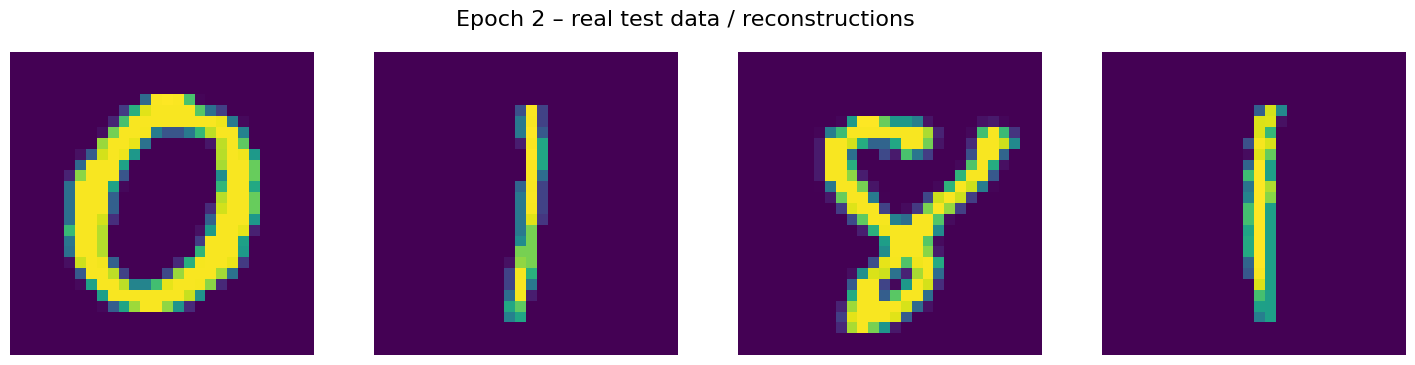

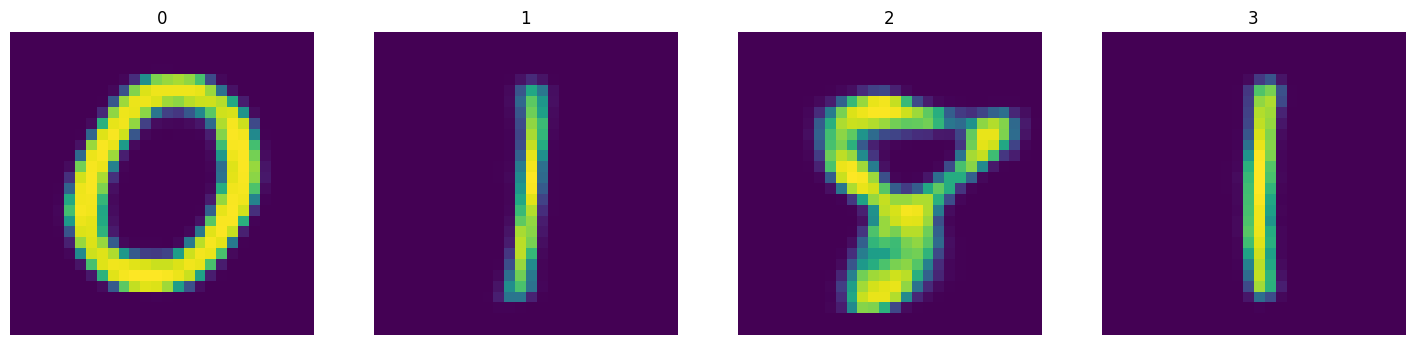

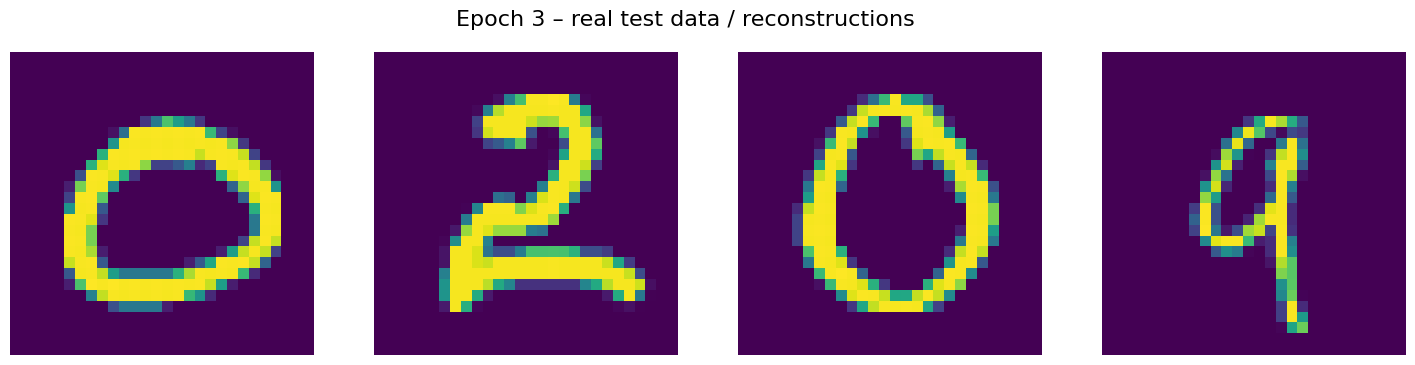

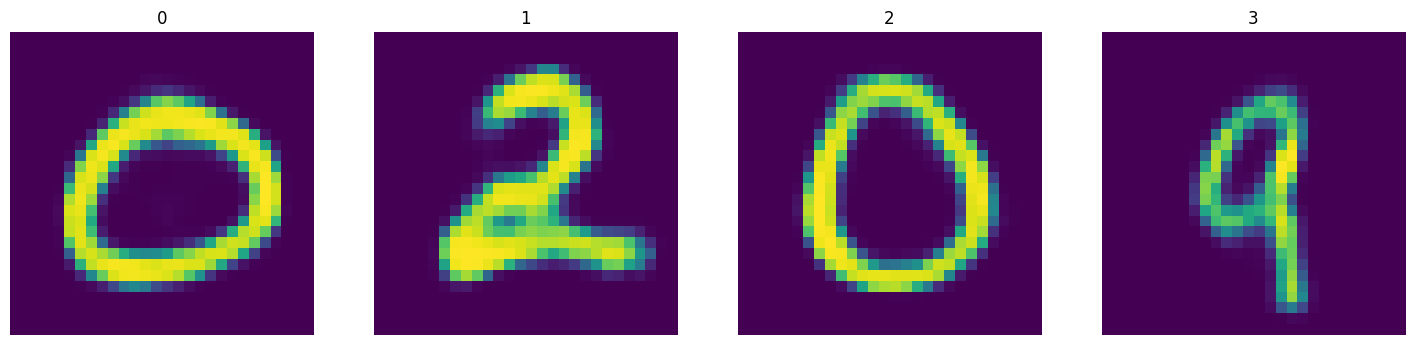

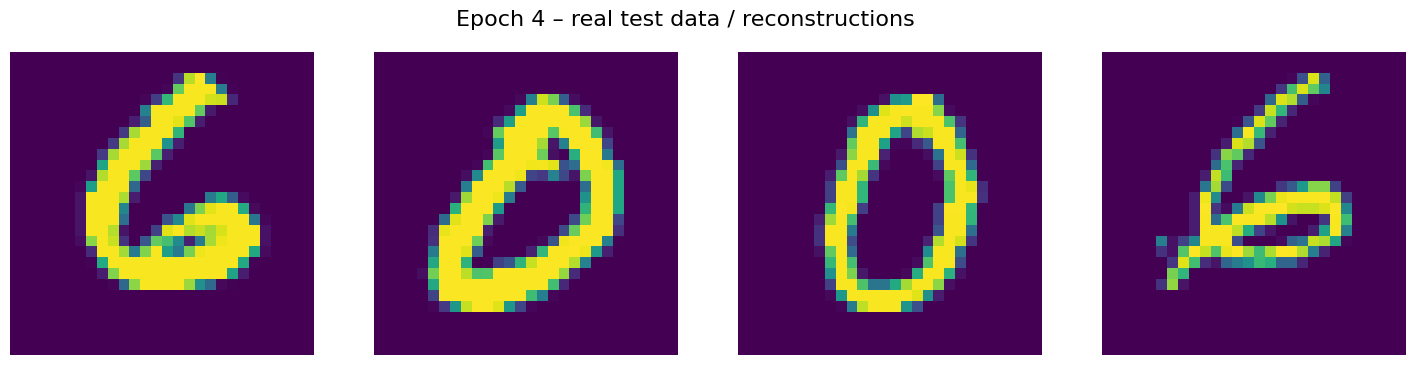

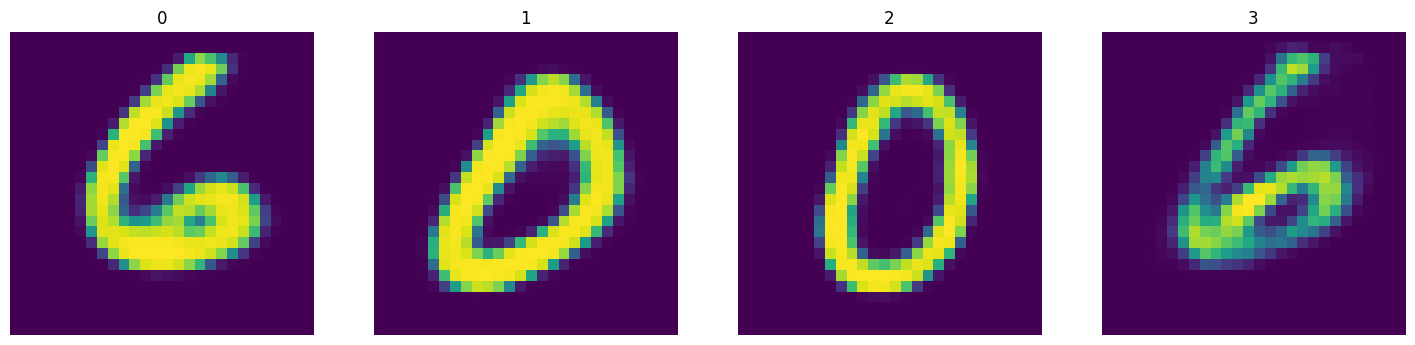

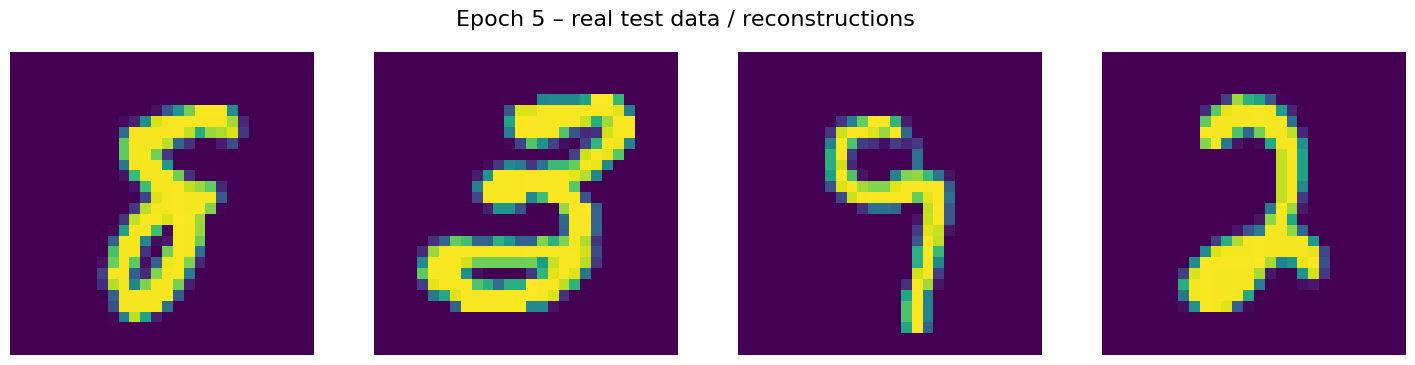

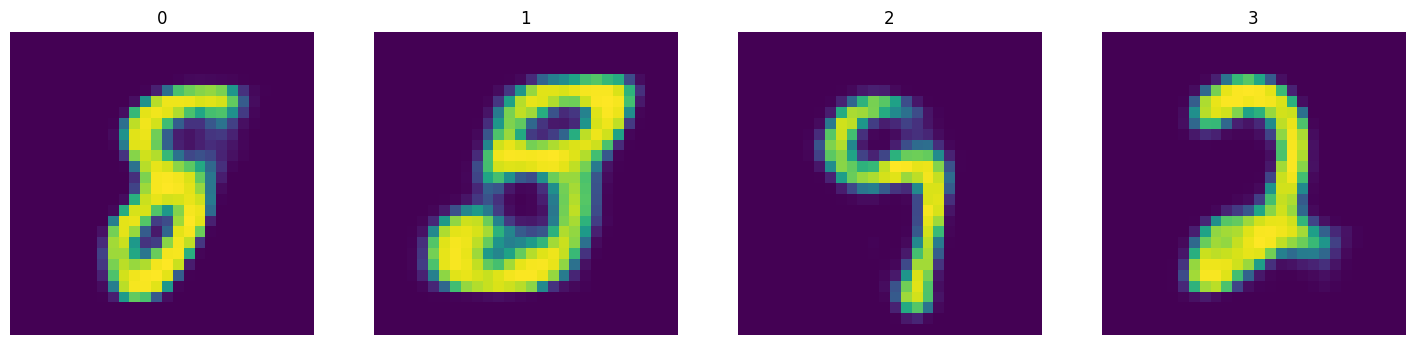

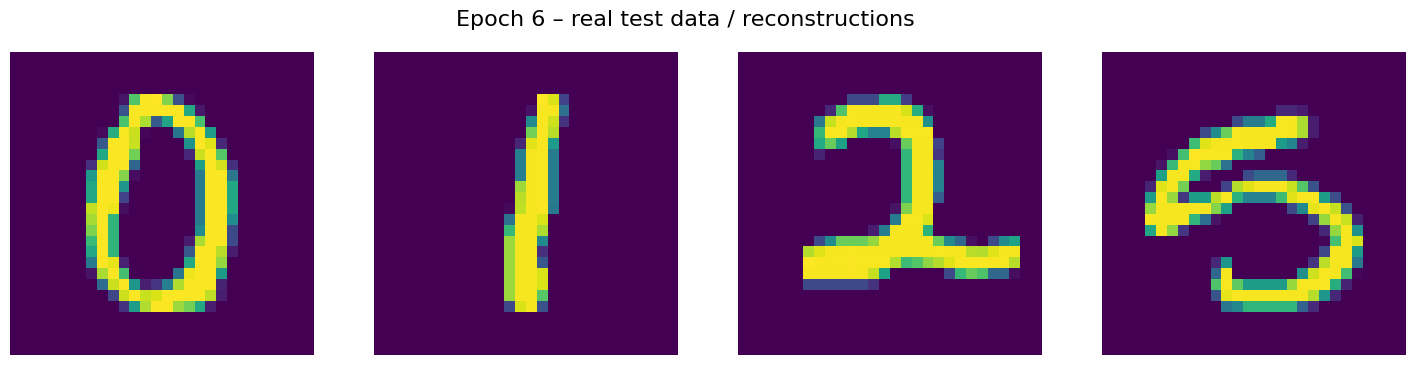

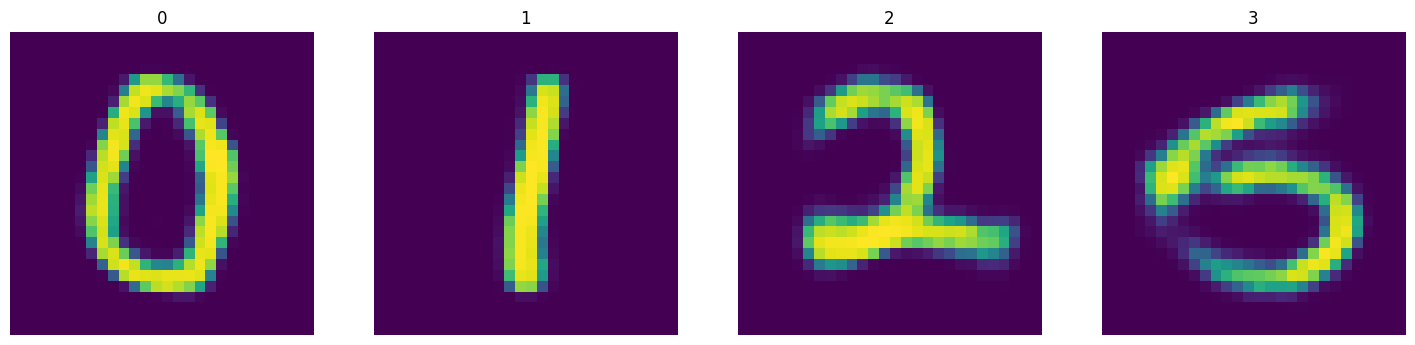

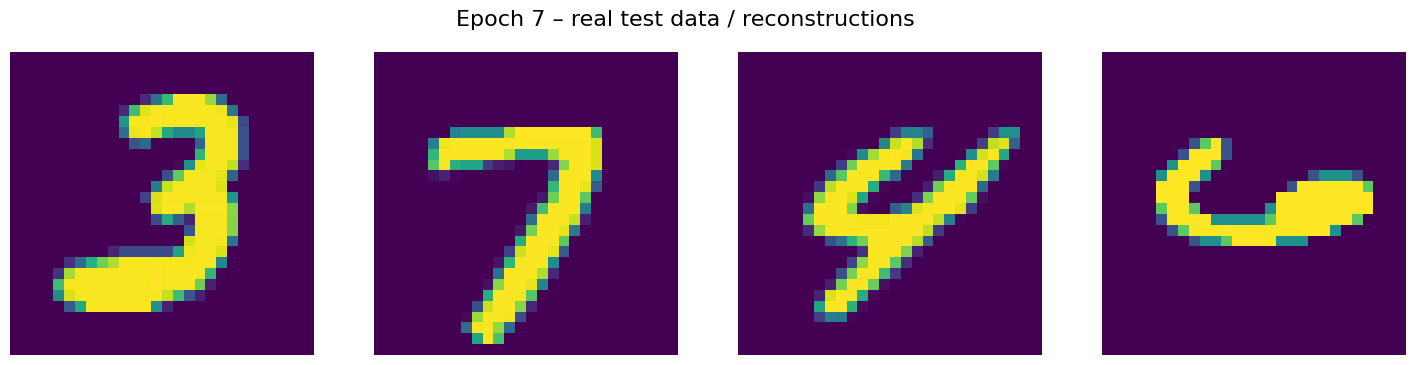

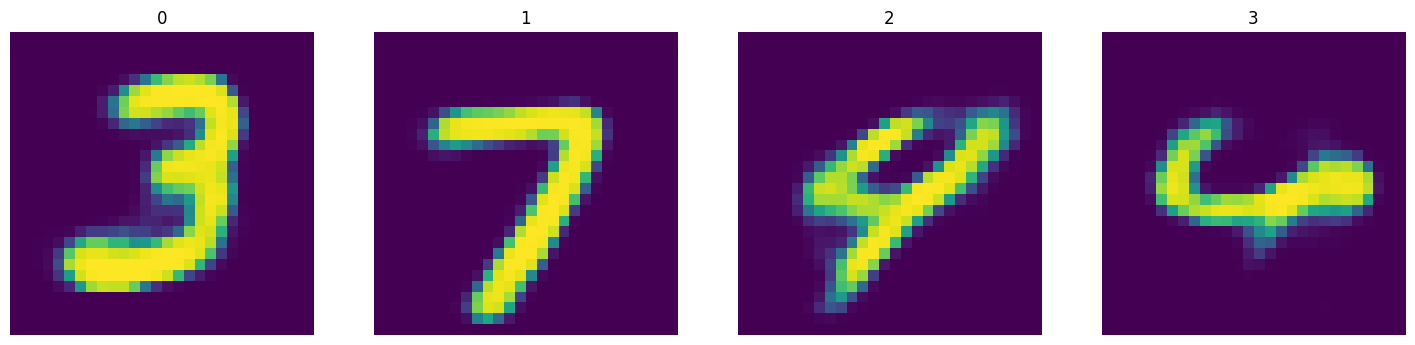

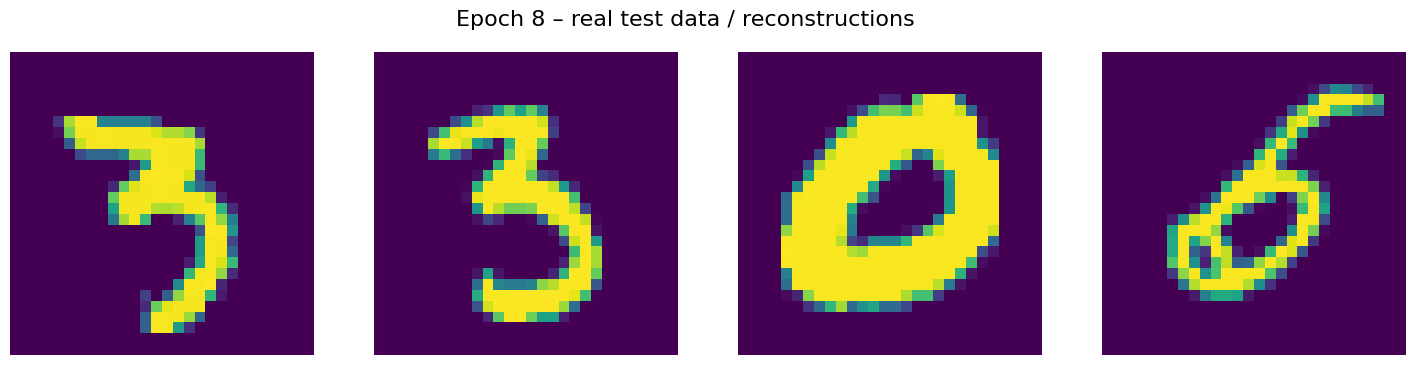

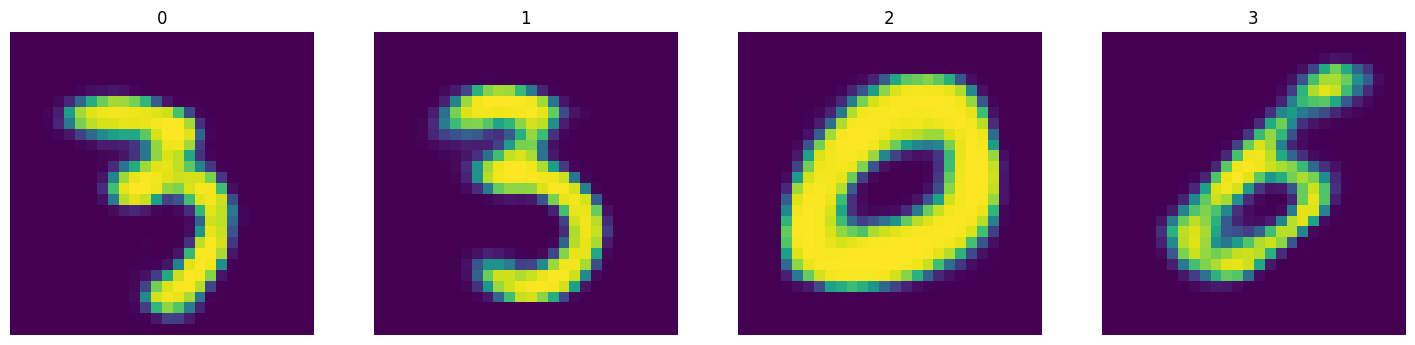

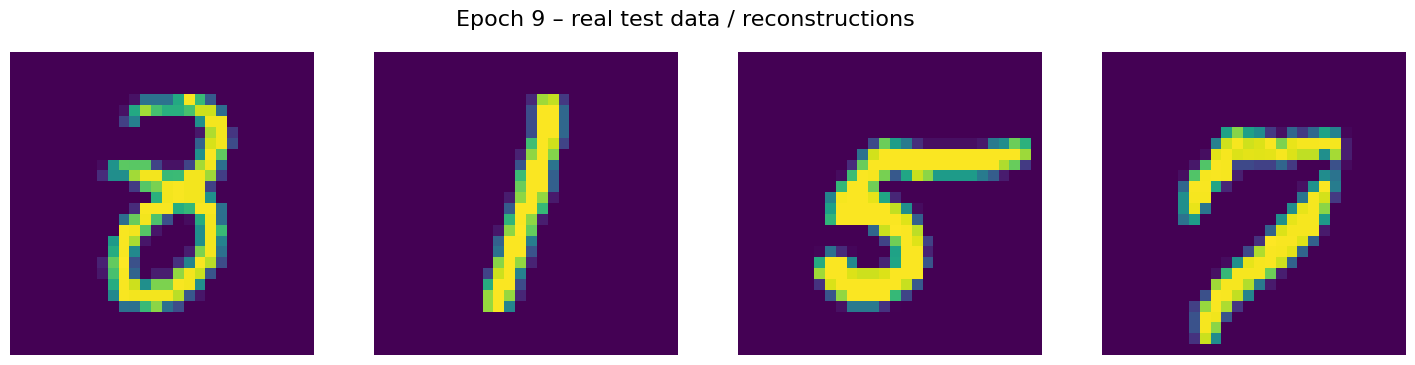

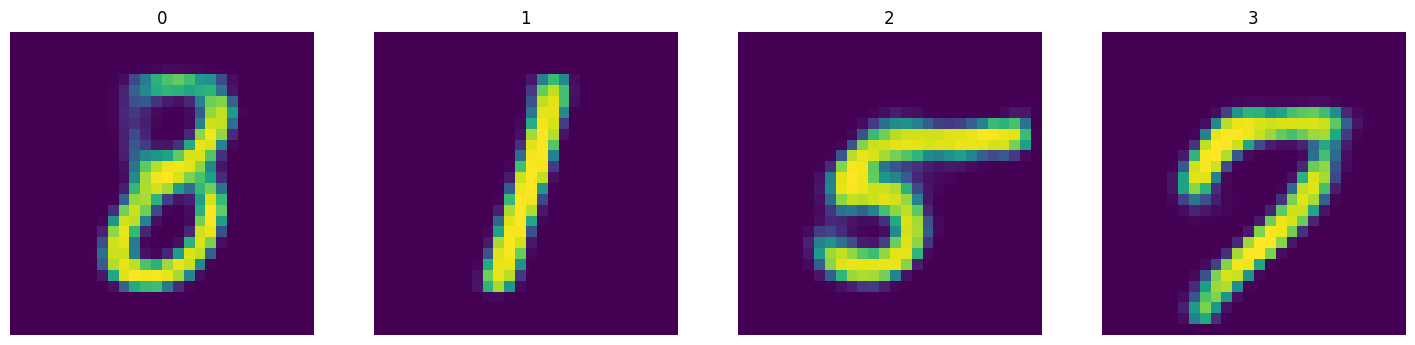

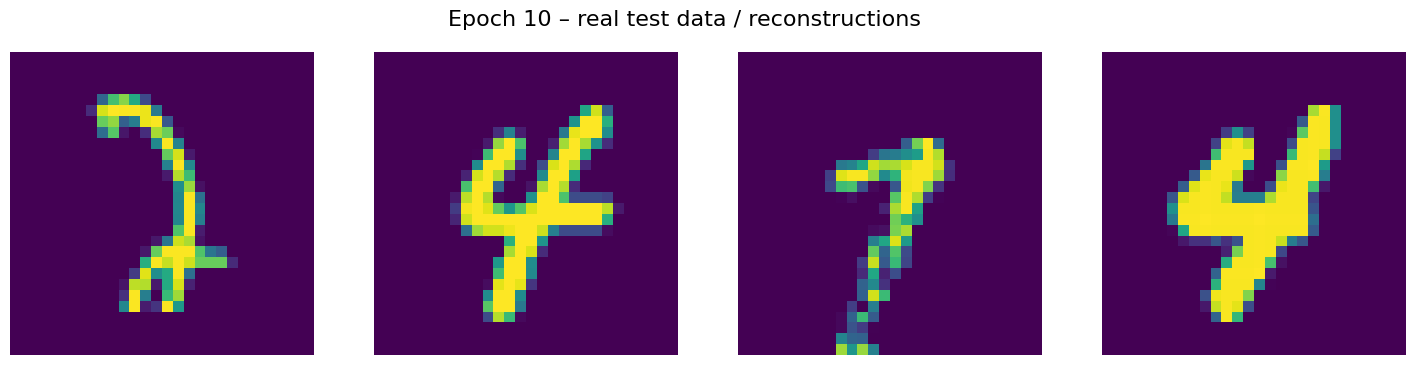

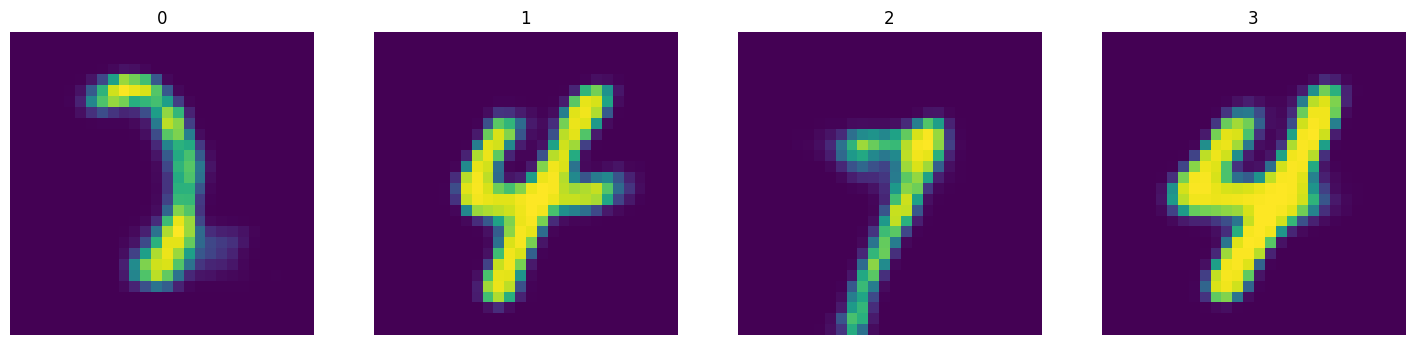

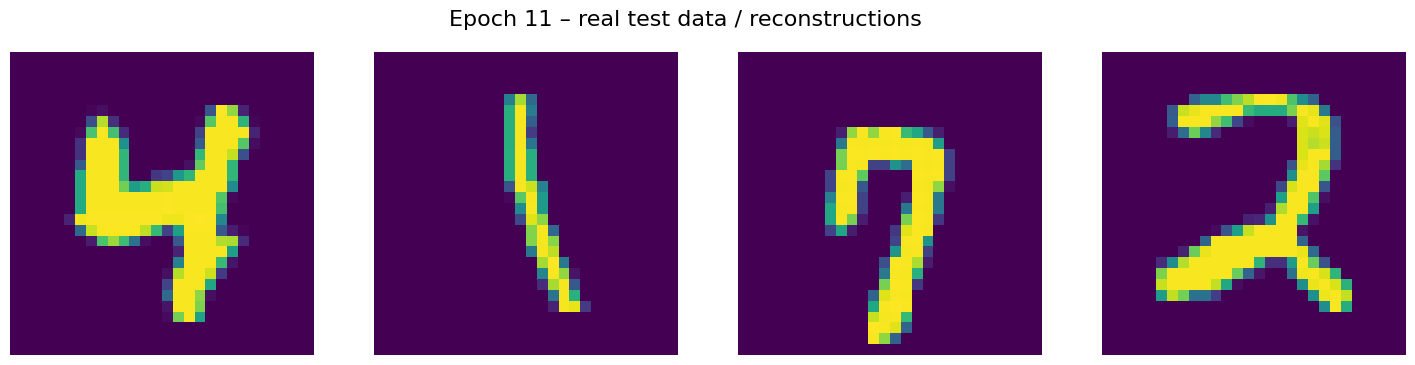

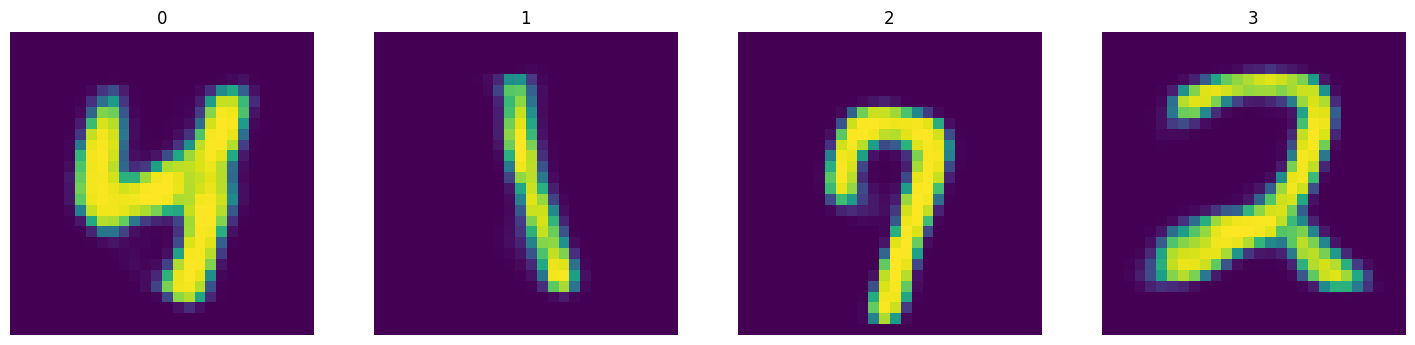

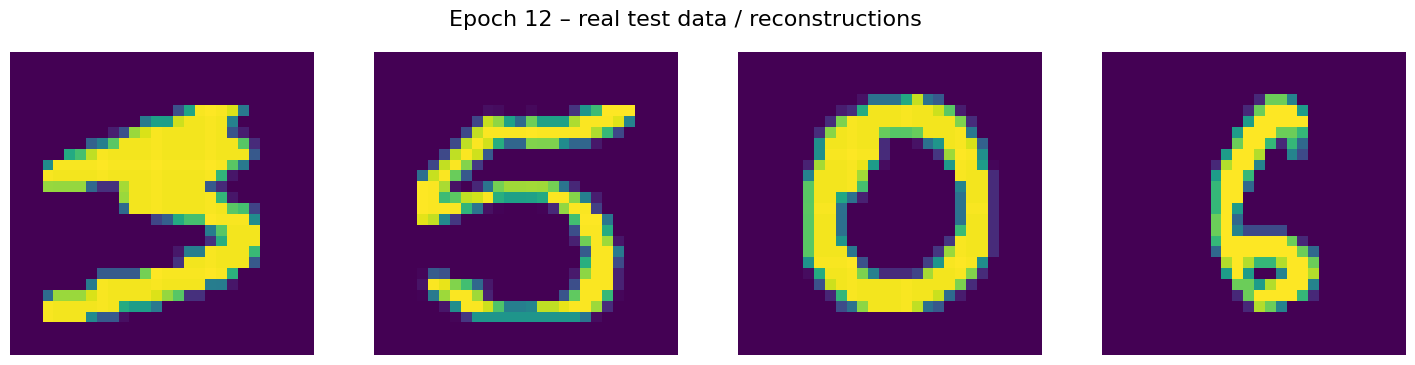

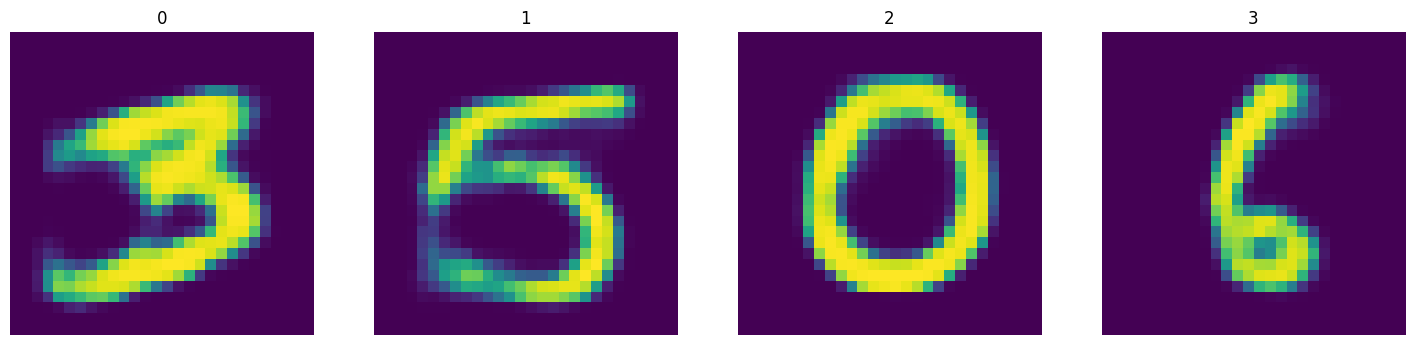

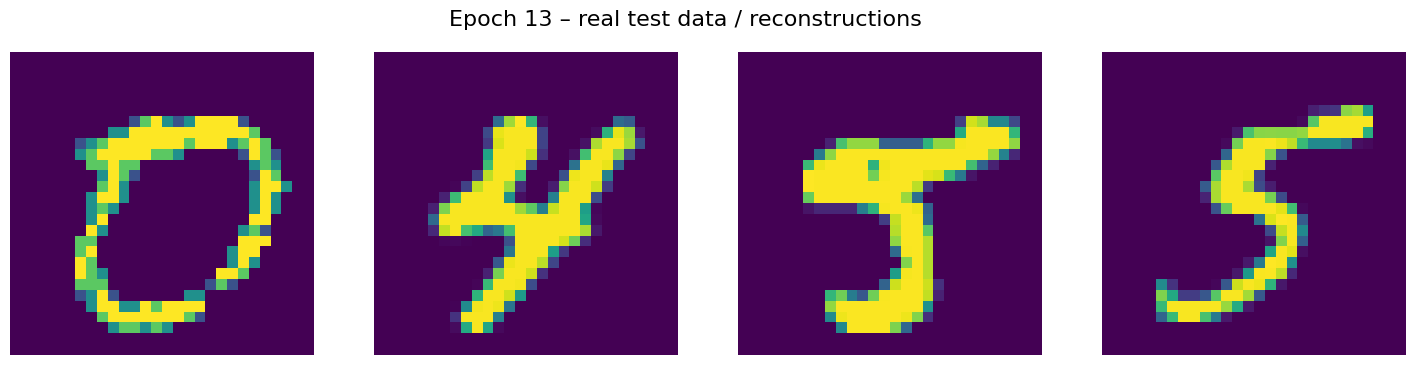

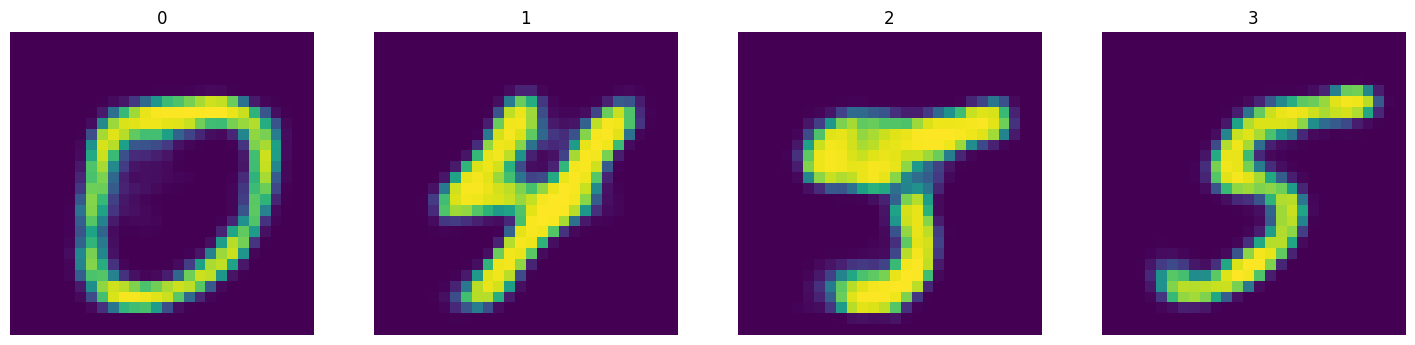

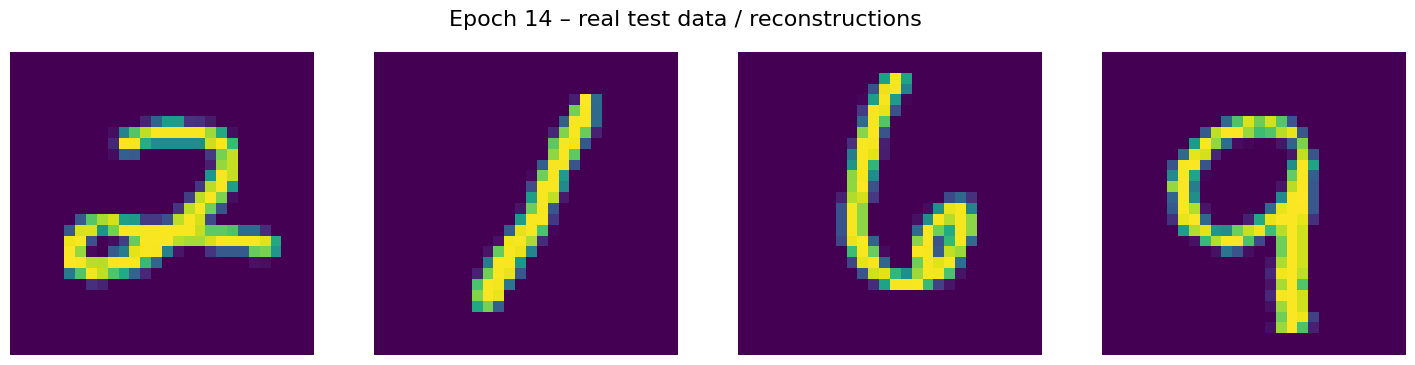

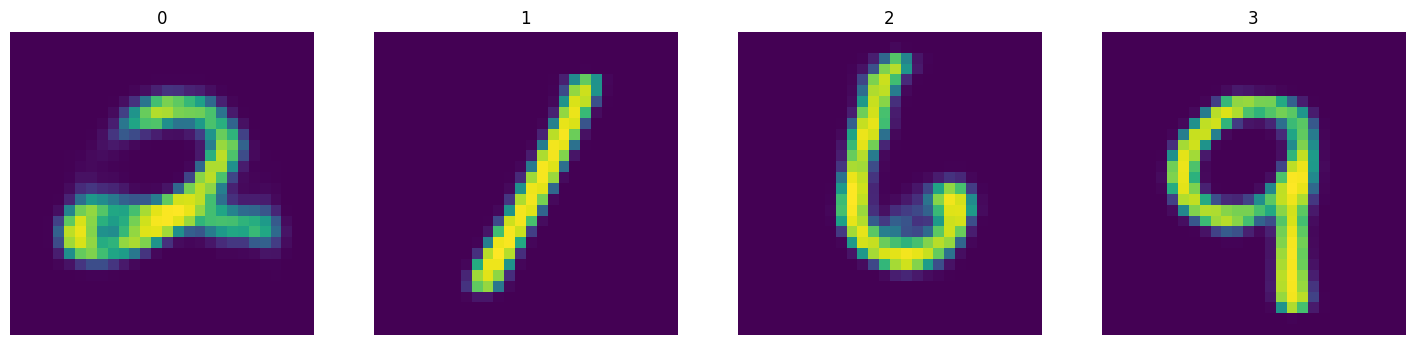

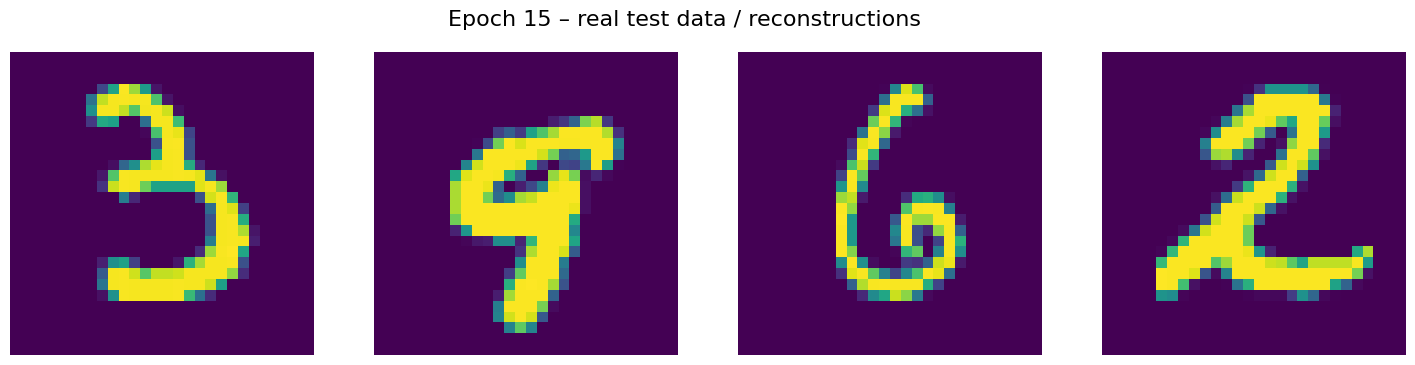

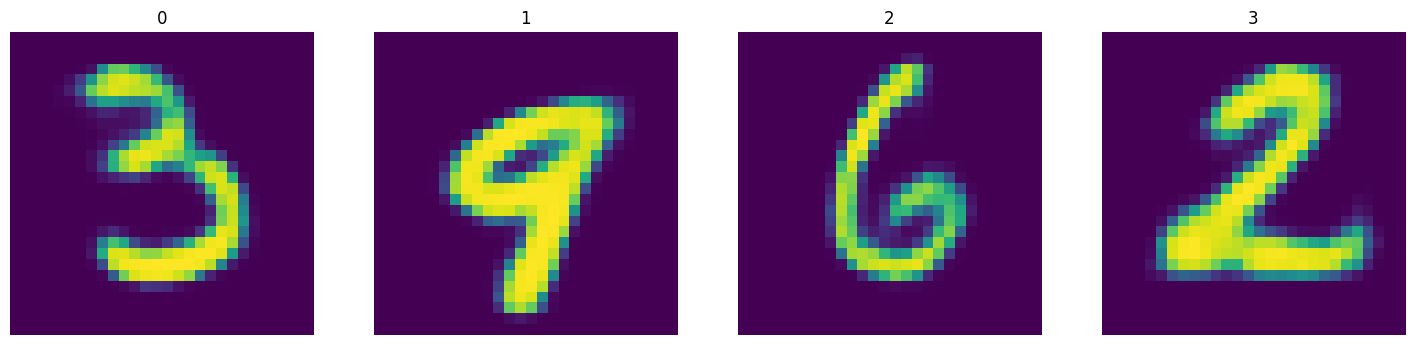

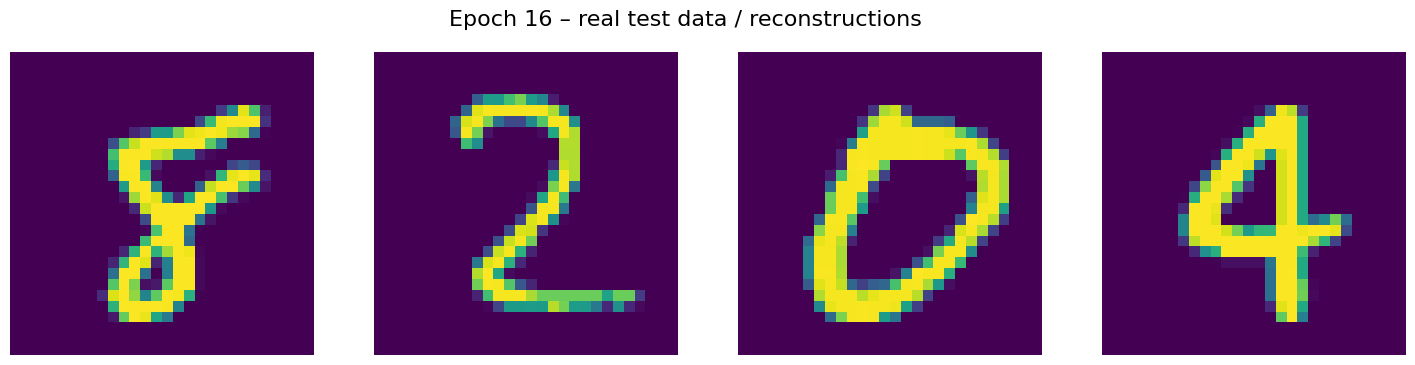

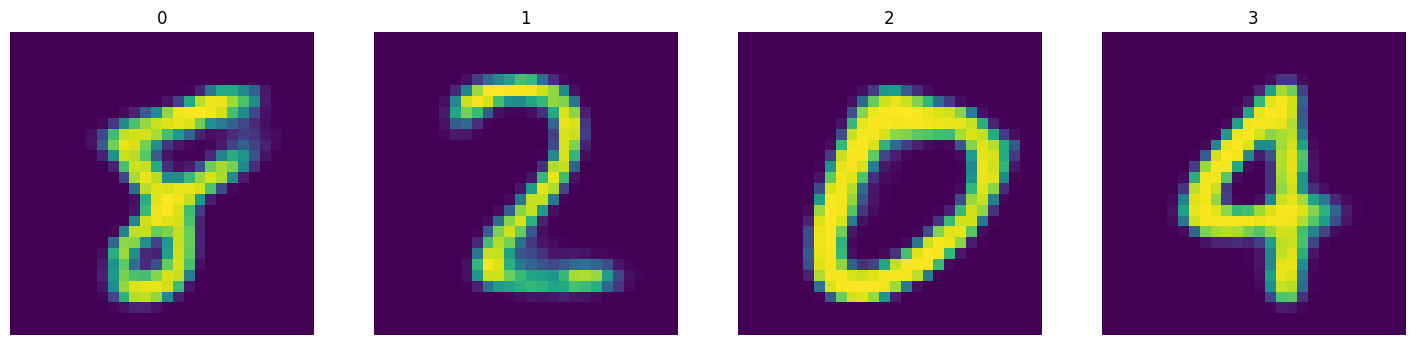

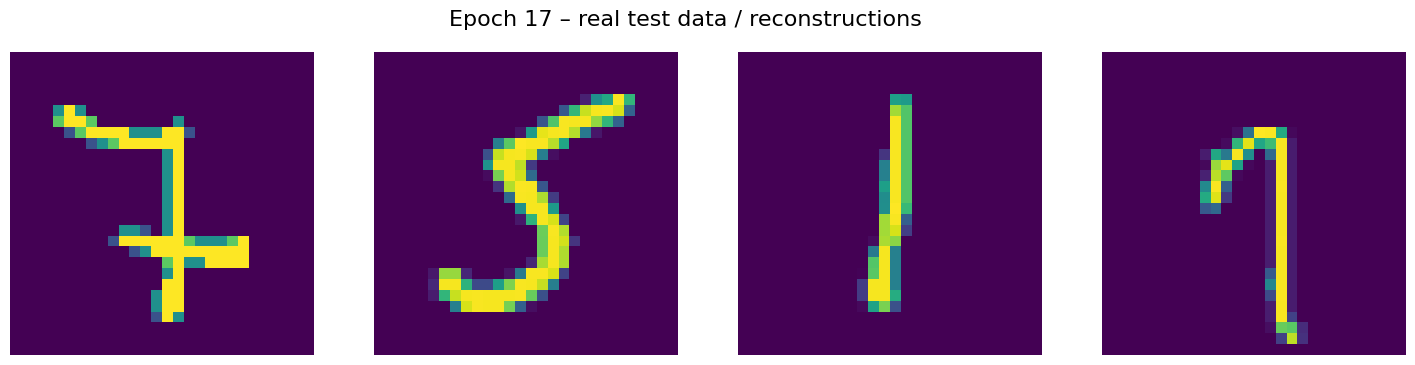

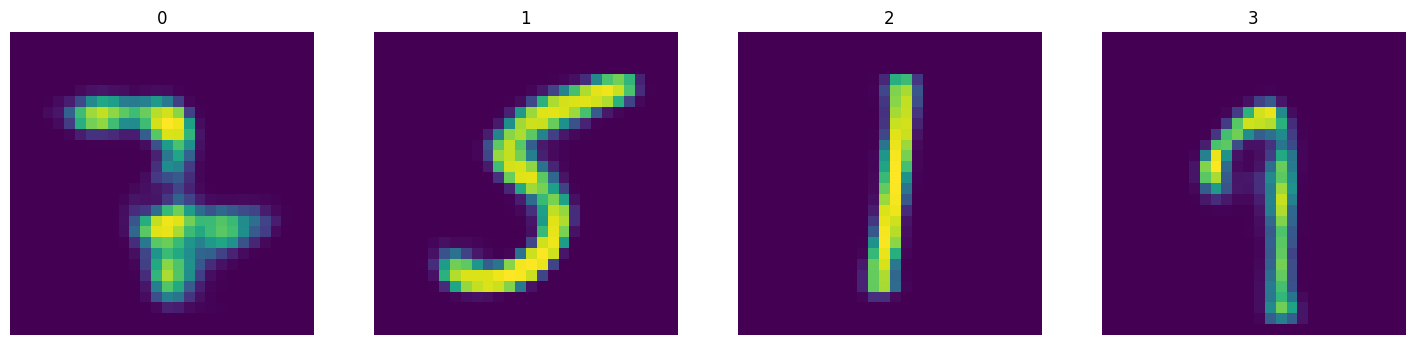

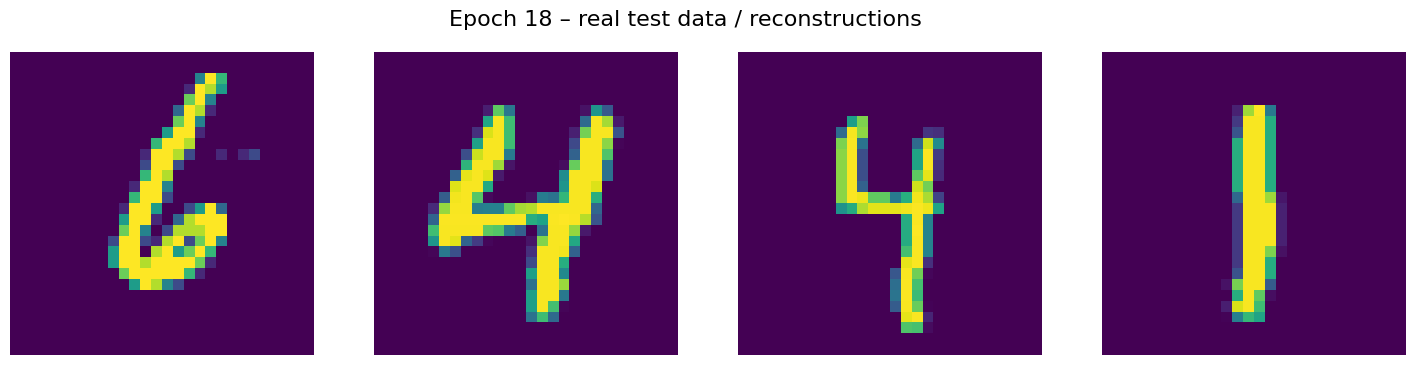

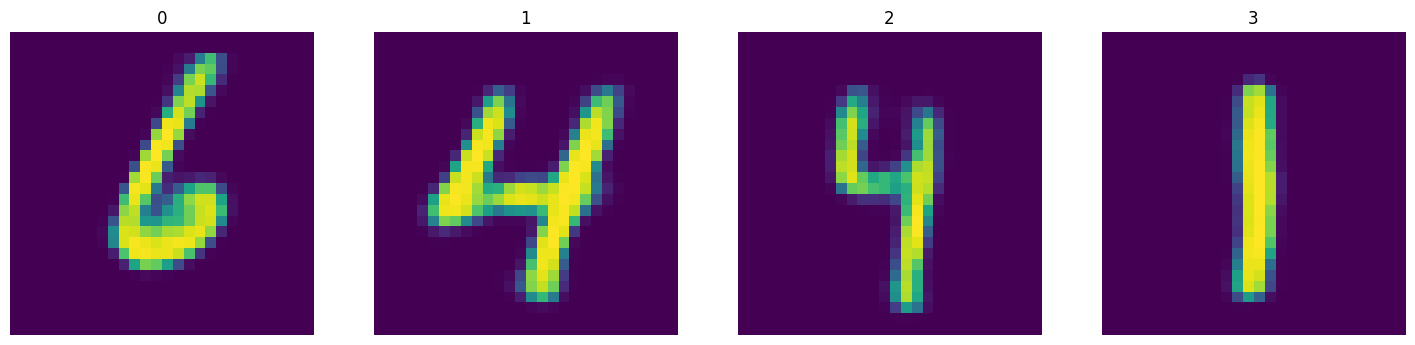

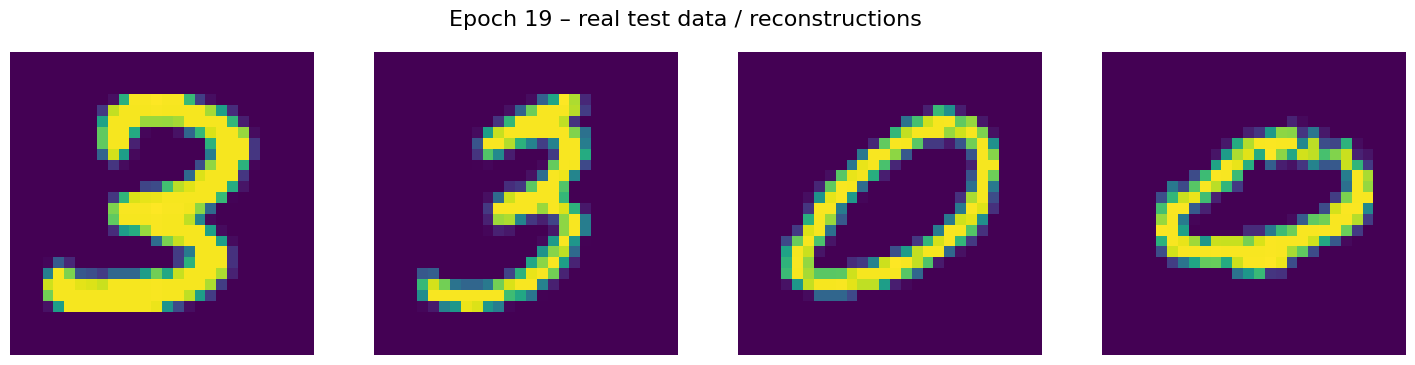

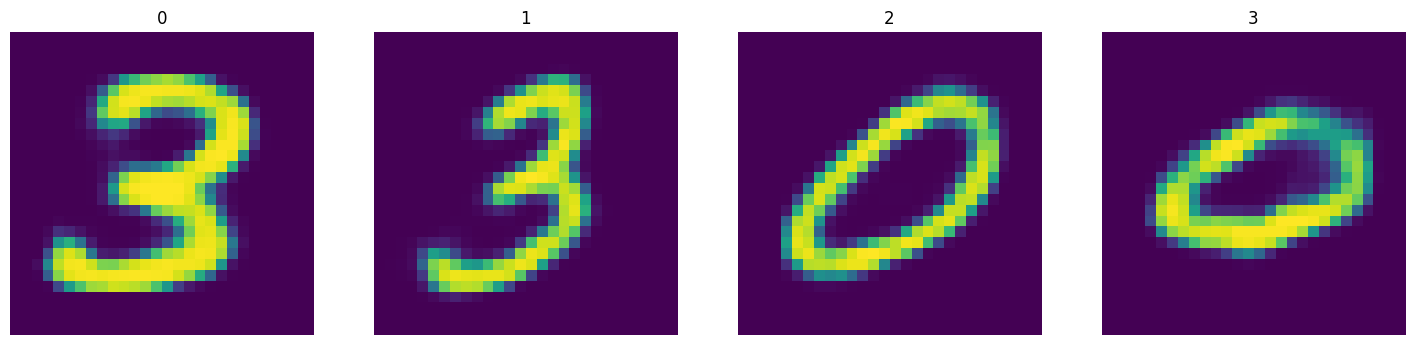

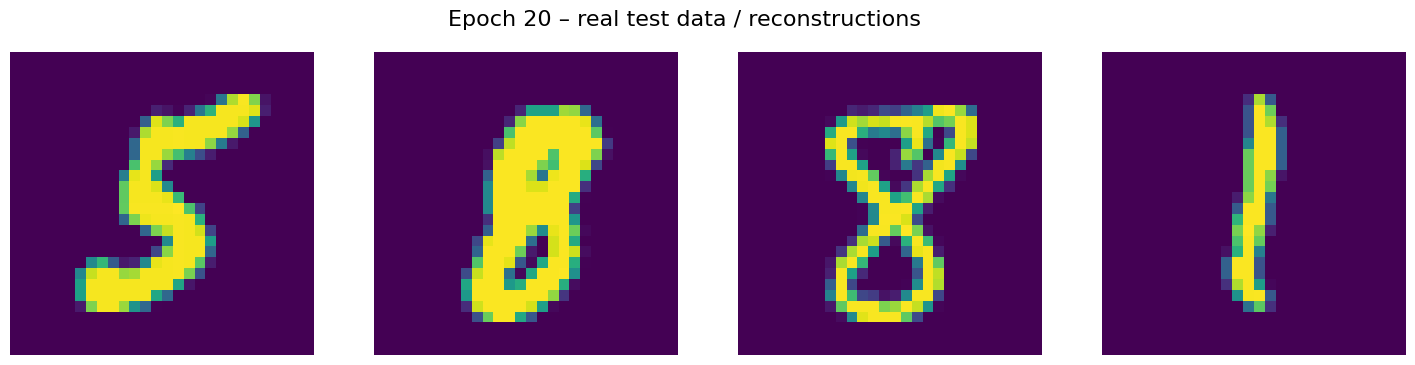

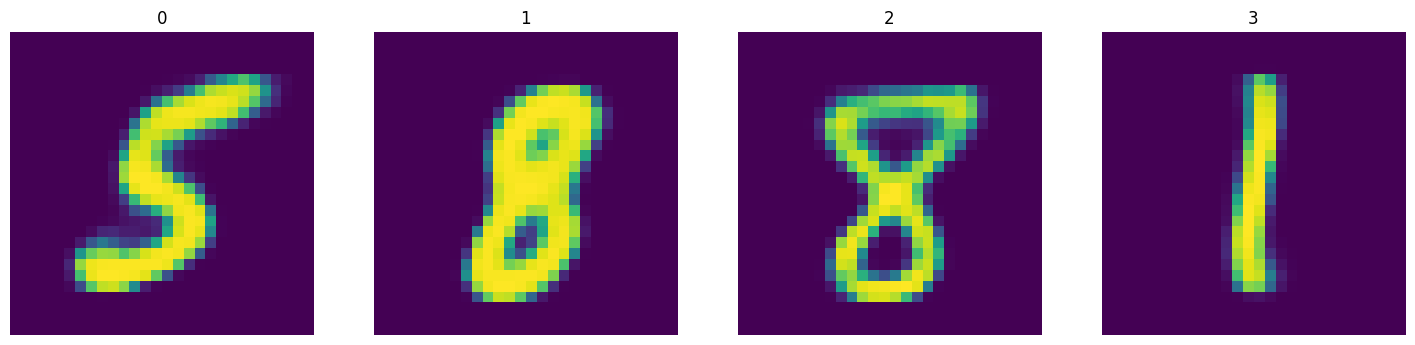

In [56]:
# Training and testing the VAE

epochs = 20
codes = dict(μ=list(), logσ2=list(), x=list())
for epoch in range(0, epochs + 1):
    # Training
    if epoch > 0:  # test untrained net first
        model.train()
        train_loss = 0
        for y, _ in train_loader:
            y = y.to(device)
            # ===================forward=====================
            ỹ, mu, logvar = model(y)
            loss = loss_function(ỹ, y, mu, logvar)
            train_loss += loss.item()
            # ===================backward====================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        # ===================log========================
        print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')
    
    # Testing
    
    means, logvars, labels = list(), list(), list()
    with torch.no_grad():
        model.eval()
        test_loss = 0
        for y, x in test_loader:
            y = y.to(device)
            # ===================forward=====================
            ỹ, mu, logvar = model(y)
            test_loss += loss_function(ỹ, y, mu, logvar).item()
            # =====================log=======================
            means.append(mu.detach())
            logvars.append(logvar.detach())
            labels.append(x.detach())
    # ===================log========================
    codes['μ'].append(torch.cat(means))
    codes['logσ2'].append(torch.cat(logvars))
    codes['x'].append(torch.cat(labels))
    test_loss /= len(test_loader.dataset)
    print(f'====> Test set loss: {test_loss:.4f}')
    display_images(y, ỹ, 1, f'Epoch {epoch}', count=True)

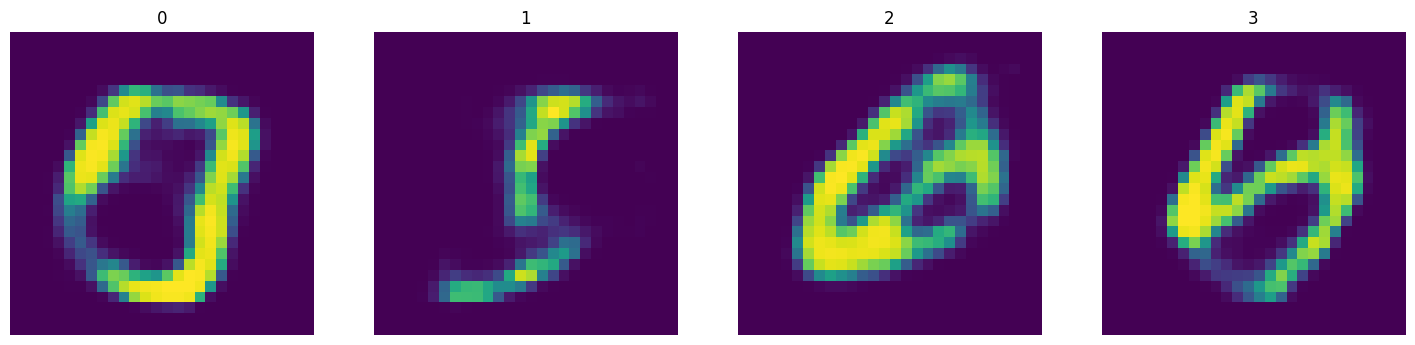

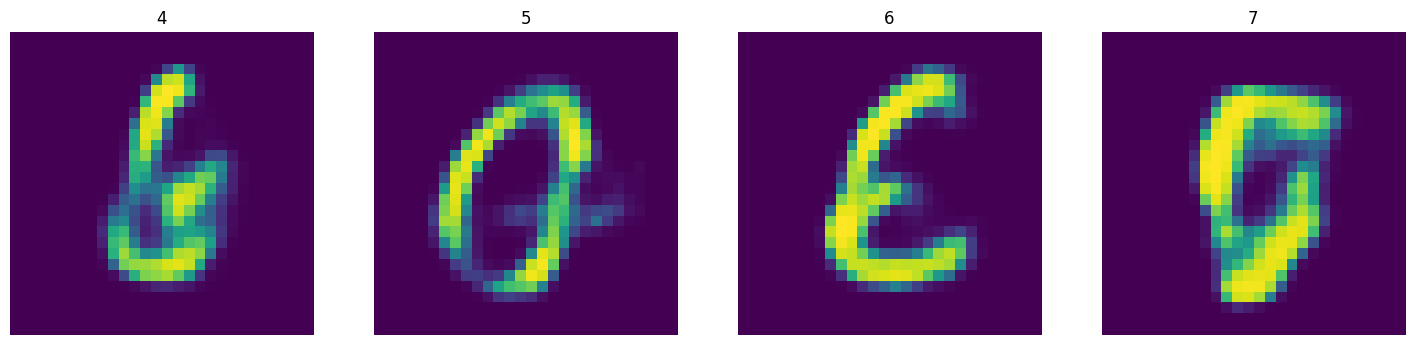

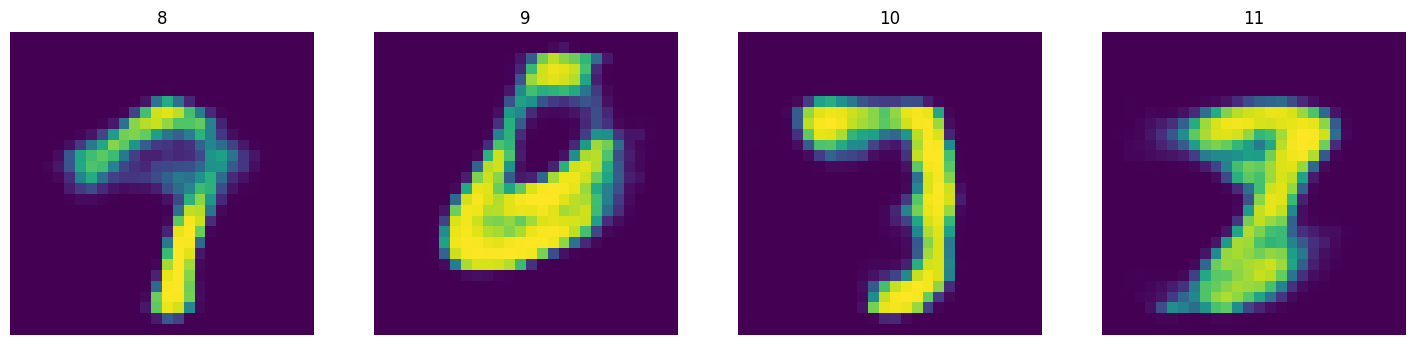

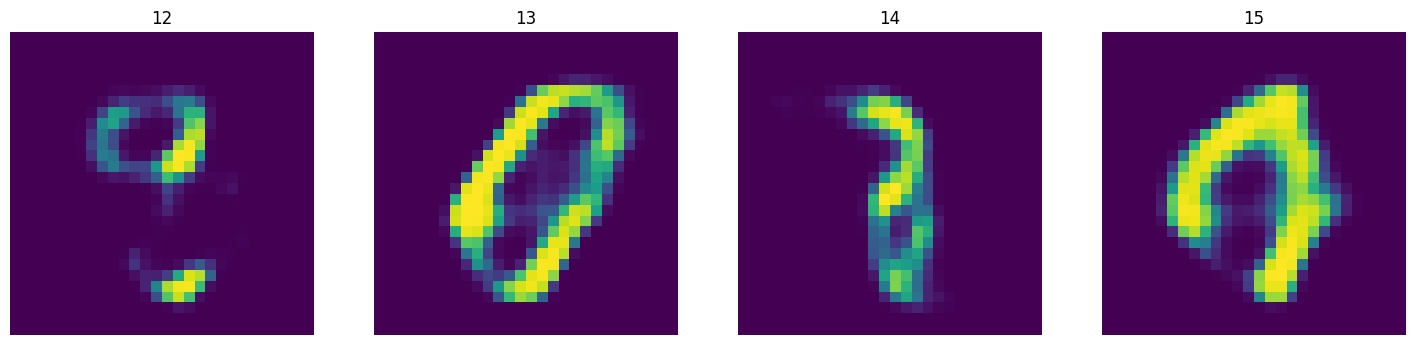

In [63]:
# Generating a few samples

N = 16
z = torch.randn((N, d)).to(device)
sample = model.decoder(z)
display_images(None, sample, N // 4, count=True)

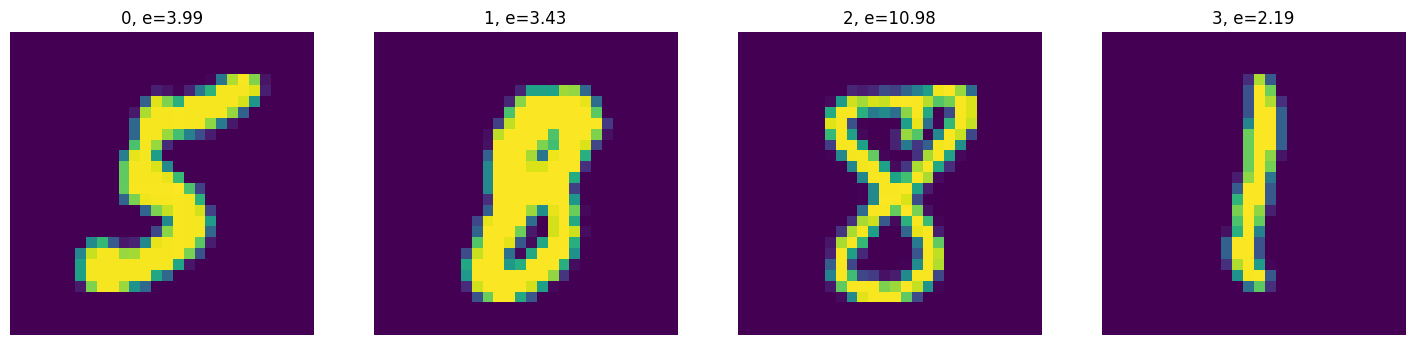

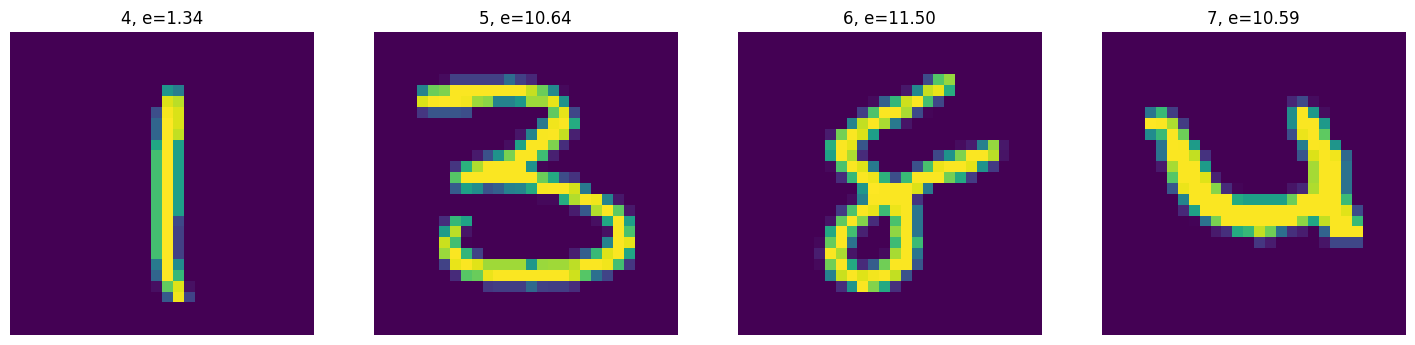

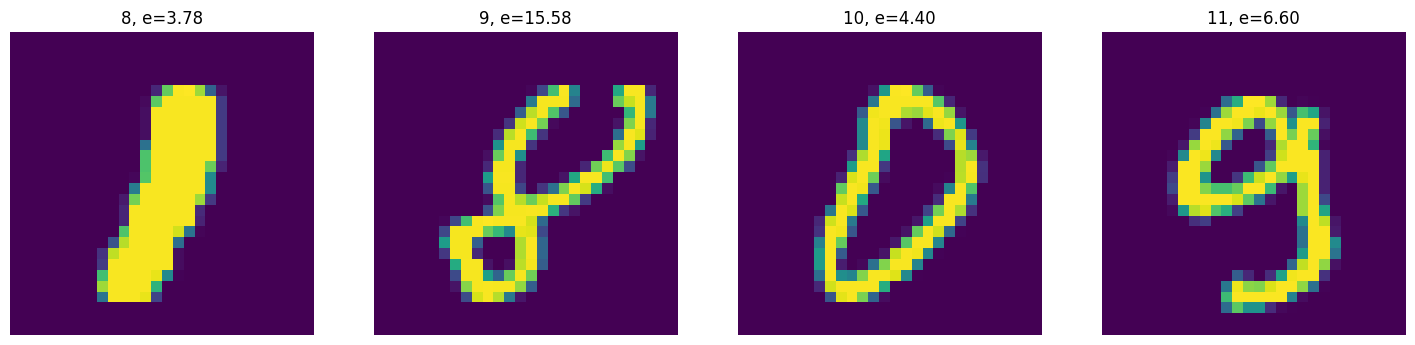

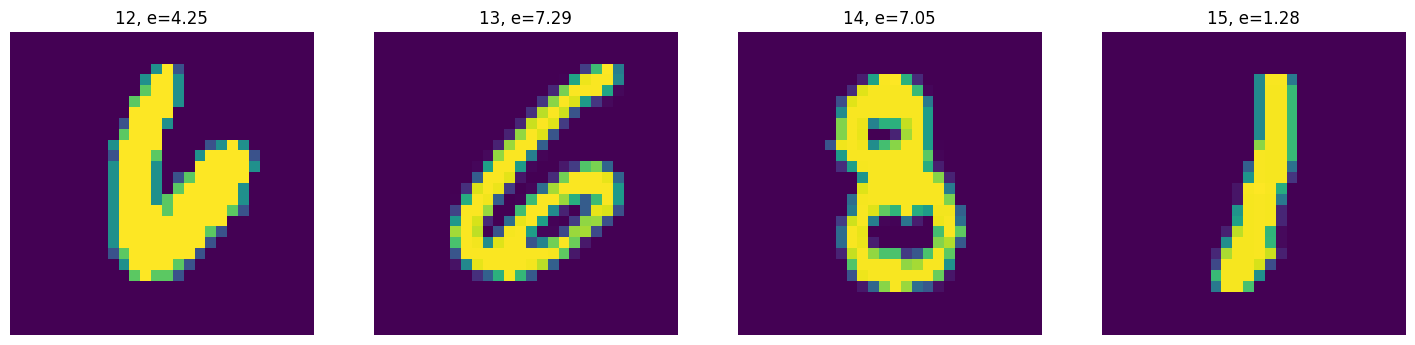

In [64]:
# Display last test batch
with torch.no_grad():
    ỹ = model(y)[0].view(-1, 28, 28)
energy = y.squeeze().sub(ỹ).pow(2).sum(dim=(1,2))
display_images(None, y, 4, count=True, energy=energy)

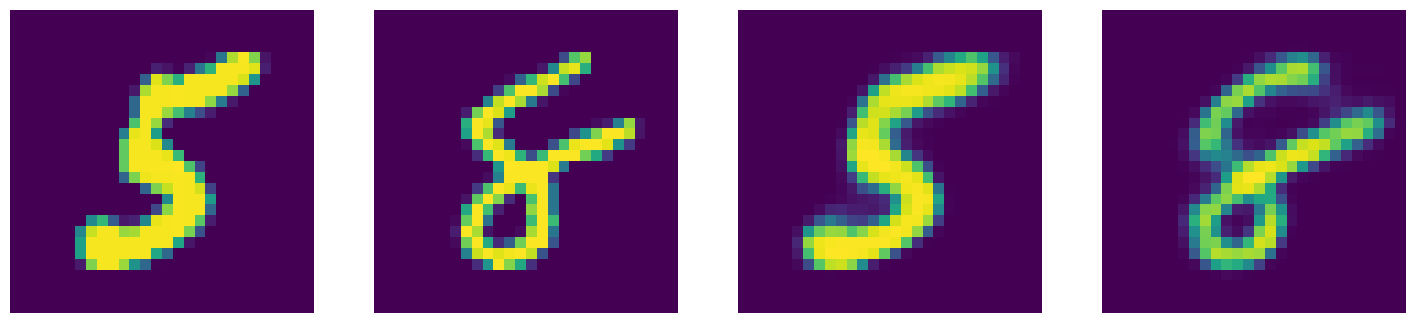

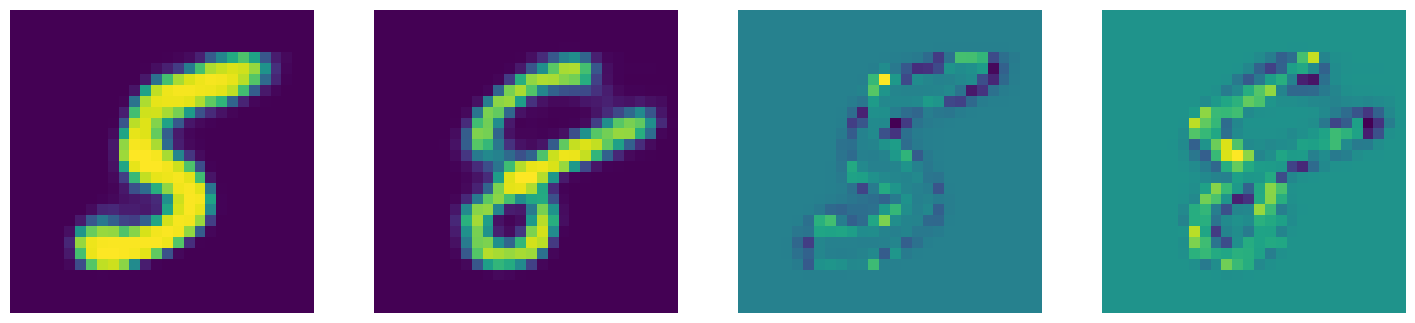

In [67]:
# Choose starting and ending point for the interpolation -> shows original and reconstructed

A, B = 0, 6
sample = model.decoder(torch.stack((mu[A].data, mu[B].data), 0))
display_images(None, torch.stack(((
    y[A].data.view(-1),
    y[B].data.view(-1),
    sample.data[0],
    sample.data[1],
    sample.data[0],
    sample.data[1],
    y[A].data.view(-1) - sample.data[0],
    y[B].data.view(-1) - sample.data[1]
)), 0), 2)

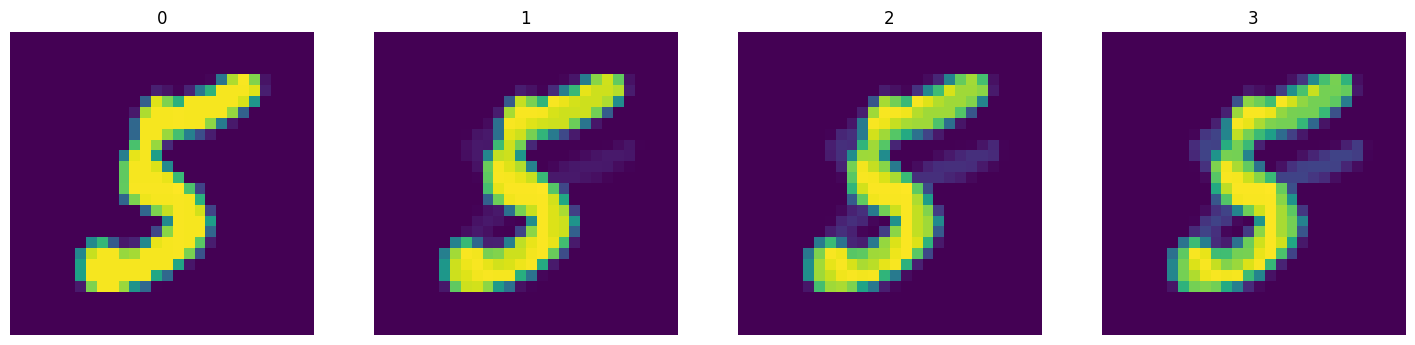

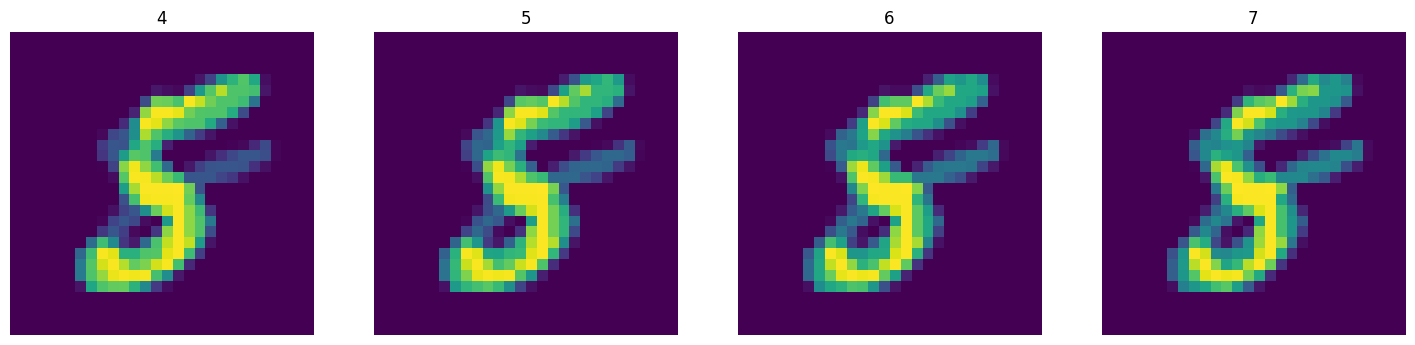

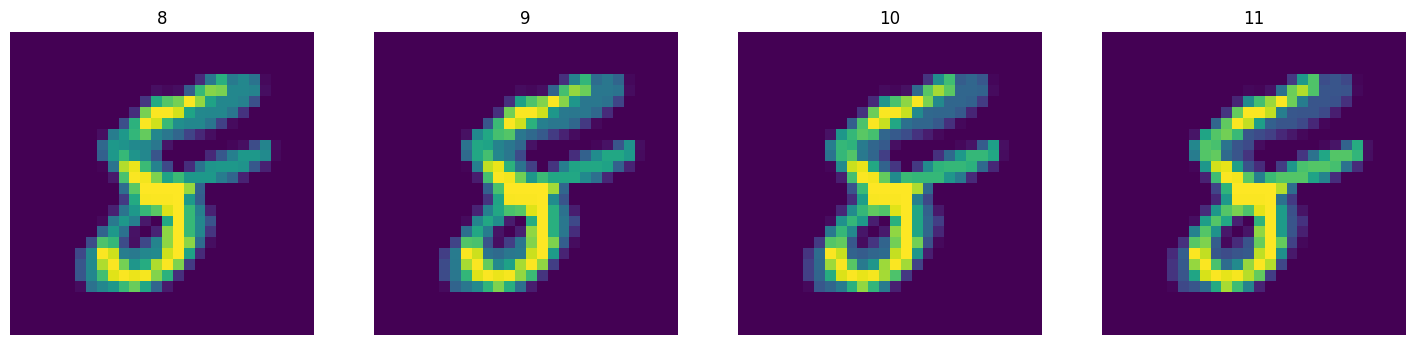

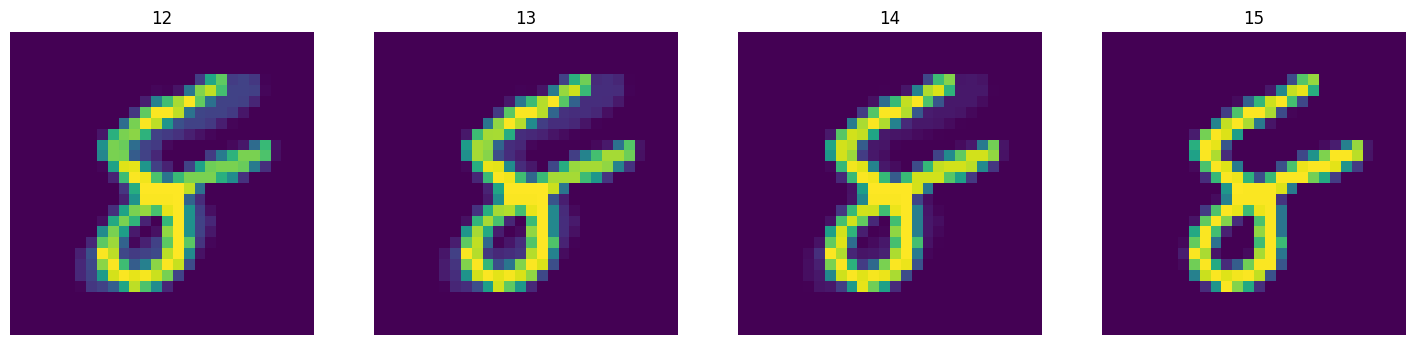

In [68]:
# Perform an interpolation between input A and B, in N steps

N = 16
# code = torch.Tensor(N, 20).to(device)
samples = torch.Tensor(N, 28, 28).to(device)
for i in range(N):
    # code[i] = i / (N - 1) * mu[B].data + (1 - i / (N - 1) ) * mu[A].data
    samples[i] = i / (N - 1) * y[B].data + (1 - i / (N - 1) ) * y[A].data
# samples = model.decoder(code)
display_images(None, samples, N // 4, count=True)

(<Axes: >, <matplotlib.image.AxesImage at 0x7a8fb6cf3b30>)

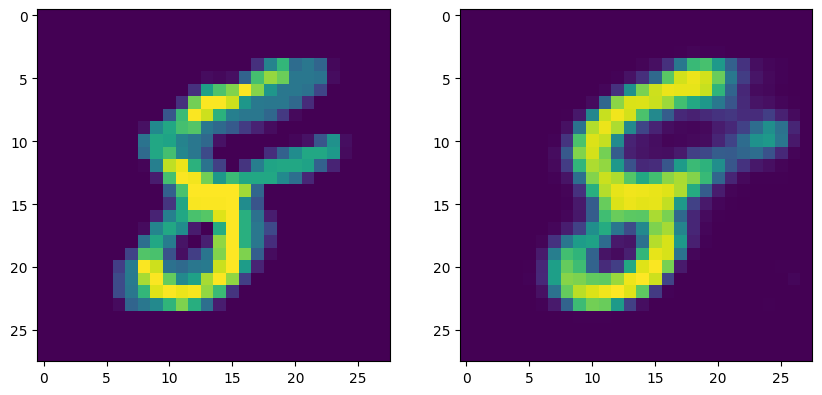

In [69]:
ẏ = samples[9]
with torch.no_grad():
    ỹ = model(ẏ)[0]
plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow((ẏ).view(28, 28))
plt.subplot(122), plt.imshow((ỹ).view(28, 28))

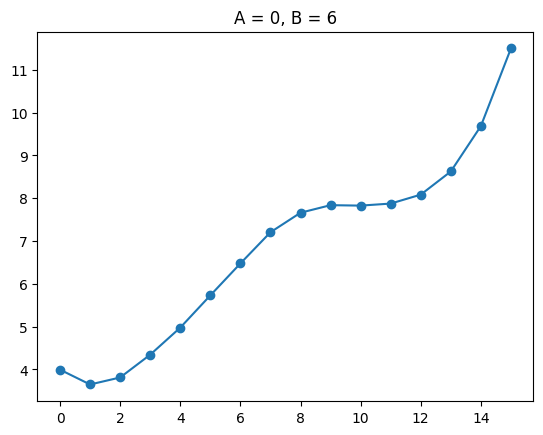

In [70]:
N = 16
samples = torch.Tensor(N, 28, 28).to(device)
for i in range(N):
    samples[i] = i / (N - 1) * y[B].data + (1 - i / (N - 1) ) * y[A].data
with torch.no_grad():
    reconstructions = model(samples)[0].view(-1, 28, 28)

plt.title(f'{A = }, {B = }')
plt.plot(samples.sub(reconstructions).pow(2).sum(dim=(1,2)), '-o')

In [71]:
import numpy as np
from sklearn.manifold import TSNE

In [83]:
X, Y, E = list(), list(), list()  # input, classes, embeddings
N = 1000  # samples per epoch
epochs = (0, 5, 10, 20)
for epoch in epochs:
    Y.append(codes['μ'][epoch][:N]) # 20 centers
    # We have 1000 of 20-th dim vectors. How to display them on 2D grid?
    # TSNE will return "optimal" layout (i.e. X and Y for each item) according to internal structure    
    E.append(TSNE(n_components=2).fit_transform(Y[-1].detach().cpu()))
    X.append(codes['x'][epoch][:N]) # x - labels

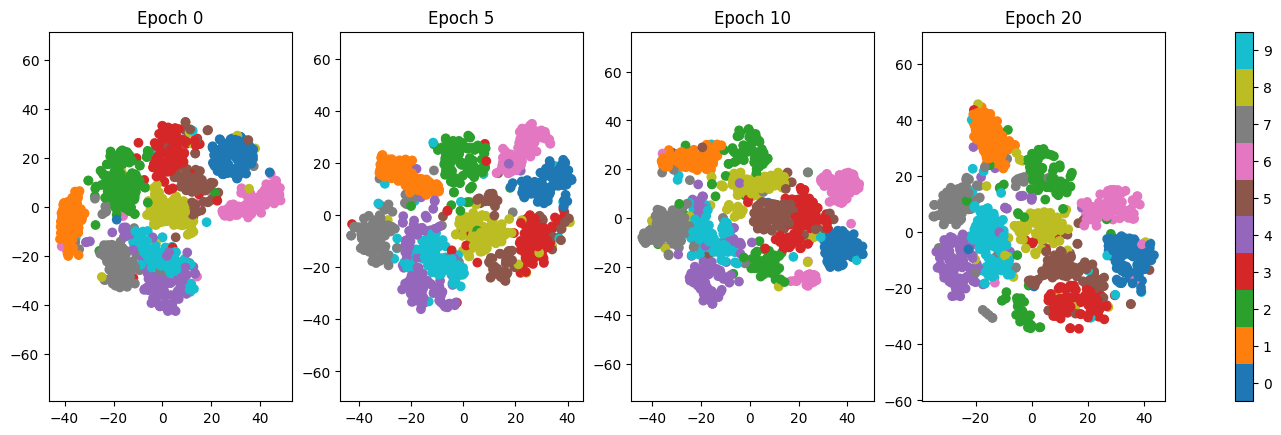

In [88]:
f, a = plt.subplots(ncols=len(E))
f.set_figwidth(18)
for i, e in enumerate(epochs):
    s = a[i].scatter(E[i][:,0], E[i][:,1], c=X[i], cmap='tab10')
    a[i].grid(False)
    a[i].set_title(f'Epoch {e}')
    a[i].axis('equal')
f.colorbar(s, ax=a[:], ticks=np.arange(10), boundaries=np.arange(11) - .5)